# 05 - Part B again: never trust the movement

**The follow-up task.** In the first version of Part B, the crop was located once and then every
commanded move was trusted. Here the camera's real position is hidden, every move is executed
with errors the navigator is not told about, and **after every move the camera works out where it
is from the image alone.** The only thing the navigator knows about a move is what it asked for.

Two versions, as asked:

- **A. With zoom:** when a view can't be located, zoom out until it can, travel zoomed out, and zoom
  back in once the marker is in view.
- **B. Without zoom:** map in advance which views *can* be located, and plan a route that stays on
  them. If a move still lands somewhere that can't be placed, undo it and route around that spot.

Code: `src/aulecv/closed_loop.py`. Tests: `tests/test_closed_loop.py`.

In [1]:
# --- Setup: locate the project, check dependencies, import the package -------
# Local Jupyter: the project is found by walking up from the working directory.
# Google Colab: Drive is mounted and searched for the project folder. A folder
# that cannot be written to (for example one shared as view-only) is copied to
# /content first, so the notebook can save its outputs.
import glob, importlib.util, os, shutil, subprocess, sys

PROJECT_NAME = "AULE_ComputerVisionChallenge"
PROJECT_DIR = ""  # optional: set this to the project folder if it is not found automatically

def _is_project(path):
    return bool(path) and os.path.isdir(os.path.join(path, "src", "aulecv"))

def _walk_up(start):
    path = os.path.abspath(start)
    while not _is_project(path):
        parent = os.path.dirname(path)
        if parent == path:
            return None
        path = parent
    return path

def _is_writable(path):
    probe = os.path.join(path, "outputs", ".write_test")
    try:
        os.makedirs(os.path.dirname(probe), exist_ok=True)
        with open(probe, "w") as fh:
            fh.write("ok")
        os.remove(probe)
        return True
    except OSError:
        return False

IN_COLAB = "google.colab" in sys.modules
PROJECT_ROOT = PROJECT_DIR if _is_project(PROJECT_DIR) else _walk_up(os.getcwd())

if PROJECT_ROOT is None and IN_COLAB:
    local_copy = os.path.join("/content", PROJECT_NAME)
    if _is_project(local_copy):
        PROJECT_ROOT = local_copy
    else:
        from google.colab import drive
        drive.mount("/content/drive")
        patterns = ["MyDrive/{}", "MyDrive/*/{}", "MyDrive/*/*/{}",
                    ".shortcut-targets-by-id/*/{}", ".shortcut-targets-by-id/*/*/{}",
                    "Shareddrives/*/{}"]
        found = [p for pat in patterns
                 for p in sorted(glob.glob(os.path.join("/content/drive", pat.format(PROJECT_NAME))))
                 if _is_project(p)]
        if not found:
            raise RuntimeError(
                "The {0} folder was not found in Google Drive. If it was shared with you, "
                "open Drive, right-click the shared folder and choose Organize > Add shortcut "
                "> My Drive, then run this cell again. Alternatively set PROJECT_DIR above."
                .format(PROJECT_NAME))
        PROJECT_ROOT = found[0]
        if not _is_writable(PROJECT_ROOT):
            shutil.copytree(PROJECT_ROOT, local_copy, dirs_exist_ok=True)
            print("Drive folder is read-only; working on a copy in", local_copy)
            PROJECT_ROOT = local_copy

if PROJECT_ROOT is None:
    raise RuntimeError("Could not find the {} folder. Open this notebook from inside it, "
                       "or set PROJECT_DIR above.".format(PROJECT_NAME))

_required = {"cv2": "opencv-python-headless", "numpy": "numpy", "pandas": "pandas",
             "matplotlib": "matplotlib", "imageio": "imageio", "PIL": "pillow"}
_missing = [pkg for mod, pkg in _required.items() if importlib.util.find_spec(mod) is None]
if _missing and IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + _missing)
elif _missing:
    raise ImportError("Missing packages: {}. Install them with: pip install -r "
                      "requirements.txt".format(", ".join(_missing)))

os.environ["AULECV_PROJECT_ROOT"] = PROJECT_ROOT
if os.path.join(PROJECT_ROOT, "src") not in sys.path:
    sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

import numpy as np, cv2, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)

from aulecv import config as C, detect, rotation, navigation, camera, viz
from aulecv import io as aio

np.random.seed(C.RANDOM_SEED)
OUT = aio.ensure_output_dirs()
print("PROJECT_ROOT :", PROJECT_ROOT)
print("outputs      :", OUT)
print("python       :", sys.version.split()[0], "| opencv", cv2.__version__, "| numpy", np.__version__)
from aulecv import closed_loop as cl

PROJECT_ROOT : D:\Aulespace\AULE_ComputerVisionChallenge
outputs      : D:\Aulespace\AULE_ComputerVisionChallenge\outputs
python       : 3.14.3 | opencv 4.13.0 | numpy 2.4.3


## 1. The problem: some views cannot be located

Template matching only works if the view contains something unique. A view showing only straight
horizontal lines looks the same all along those lines. Re-localising at every step of the
**original** Part B plan shows how often that happens.

In [2]:
reference = aio.load_reference()
ref_det = detect.detect_port(reference)
VIEW = (200, 170)
ppc = navigation.pixels_per_cm(ref_det)

loc0 = navigation.localize_crop(navigation.extract_crop(reference, 400, 380, *VIEW), reference)
plan0 = navigation.plan_crop_movements(loc0, ref_det, reference.shape)
statuses = [navigation.localize_crop(navigation.extract_crop(reference, *c.window_after), reference).status
            for c in plan0.commands]
runs, prev = [], None
for k, s in enumerate(statuses, 1):
    if s != prev: runs.append([k, k, s]); prev = s
    else: runs[-1][1] = k
for a, b, s in runs:
    print(f"steps {a:>2} to {b:<2}: {s}")
print(f"\n{statuses.count('ambiguous')} of {len(statuses)} views along the original route cannot be located on their own.")

steps  1 to 8 : ok
steps  9 to 36: ambiguous
steps 37 to 65: ok

28 of 65 views along the original route cannot be located on their own.


In the middle stretch the view only contains the bottom horizontal lines, so it knows its height but
not how far left or right it is (the aperture problem). The original plan got through it only by
trusting its own moves. With real motion errors, that doesn't work, as section 3 shows.

## 2. The simulated camera

`cl.PanCamera` keeps the true position to itself. The navigator can only:

- `capture()` to get the current view,
- `move_cm(dx, dy)` to ask for a move, which is executed with a **scale error per axis, a bias, and
  random noise**,
- `set_zoom(s)`, where zoom `s` shows `s` times more of the scene in the same number of pixels.

For the example below the camera really moves only **75%** of what it's told left and right,
**120%** up and down, plus a small bias and noise. The navigator doesn't know any of that.

In [3]:
START = (500.0, 465.0)                     # centre of the original Part B crop
ERR = cl.MotionError(gain=(0.75, 1.2), bias_px=(0.5, -0.5), noise_px=1.0, seed=7)
PAD = 300                                  # plain background around the port, so zoomed-out views fit
loc_native = cl.Localizer(reference, VIEW)
loc_padded = cl.Localizer(reference, VIEW, pad=PAD)

def truly_visible(c):
    return navigation.marker_visible(c.true_window(), ref_det, "auto")

def show_paths(ax, cams_and_labels, title):
    viz.show(reference, title, ax=ax)
    mk = ref_det.marker_center
    ax.add_patch(plt.Circle(mk, ref_det.marker_radius_px, fill=False, color="red", lw=1.5))
    for c, label, style in cams_and_labels:
        t = np.array(c.trail)
        ax.plot(t[:, 0], t[:, 1], style, lw=1.6, ms=3, label=label)
    ax.legend(loc="lower right", fontsize=8)

## 3. The old way: trust the movement

Localise once, compute the route, and send every move without looking again.

believes it arrived      : True
marker really in view    : False
where it thinks it is vs where it is: 114.1 px apart


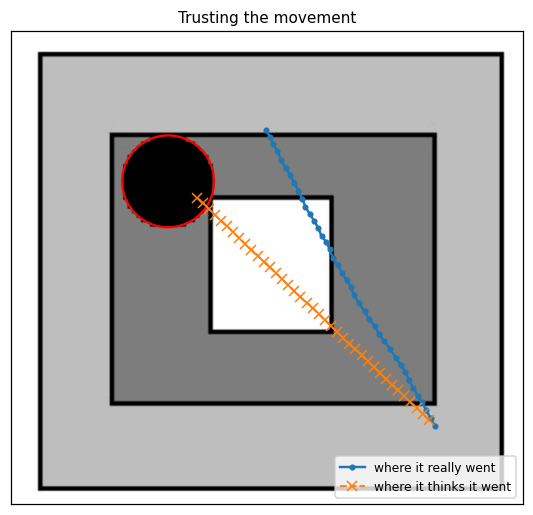

In [4]:
cam_trust = cl.PanCamera(reference, START, VIEW, ppc, ERR)
r_trust = cl.navigate_trusting_motion(cam_trust, loc_native, ref_det, reference.shape)
print("believes it arrived      :", r_trust.status == "visible")
print("marker really in view    :", truly_visible(cam_trust))
print("where it thinks it is vs where it is: {:.1f} px apart".format(r_trust.final_error_px(cam_trust)))
believed = np.array([[e["believed_x"], e["believed_y"]] for e in r_trust.log])
fig, ax = plt.subplots(figsize=(6, 5.6))
show_paths(ax, [(cam_trust, "where it really went", "o-")], "Trusting the movement")
ax.plot(believed[:, 0], believed[:, 1], "x--", lw=1.2, label="where it thinks it went"); ax.legend(loc="lower right", fontsize=8)
fig.savefig(aio.output_path("crop_navigation", "followup_trust_motion.png"), bbox_inches="tight"); plt.show()

It reports success, but the marker isn't in view. That's the dangerous failure: being wrong
**without knowing it**.

## 4. Subtask A: with zoom

After every move the view is located again by template matching at the current zoom. A view at
zoom `s` shows the scene shrunk by `s`, so it's matched against a copy of the scene shrunk by the
same amount.

1. **Located:** move towards the marker.
2. **Not located:** zoom out one step (1, 1.5, 2, 3) and look again. Zoomed out, the view contains
   more structure, so it can usually be placed.
3. **Keep travelling** at the zoom that worked.
4. **Once the estimated native view holds the marker:** zoom back in to 1 and confirm from a
   native-zoom fix.

The zoom setting itself is assumed to be read back from the lens.

In [5]:
cam_zoom = cl.PanCamera(reference, START, VIEW, ppc, ERR, pad=PAD, max_zoom=3.0)
r_zoom = cl.navigate_with_zoom(cam_zoom, loc_padded, ref_det, reference.shape, axis_first=True)
print("status:", r_zoom.status, "| marker really in view:", truly_visible(cam_zoom))
print("moves:", r_zoom.moves, "| zoom changes:", r_zoom.zoom_changes, "| views it could not place:", r_zoom.lost_views)
print("final estimate vs truth: {:.2f} px".format(r_zoom.final_error_px(cam_zoom)))
events = pd.DataFrame(r_zoom.log)
display(events[events.event != "move"][["moves", "zoom", "status", "event", "est_x", "est_y", "true_x", "true_y"]])

status: visible | marker really in view: True
moves: 59 | zoom changes: 2 | views it could not place: 1
final estimate vs truth: 0.20 px


,moves,zoom,status,event,est_x,est_y,true_x,true_y
5,5,1.0,ambiguous,zoom out,471.00,450.0,471.34,449.64
60,59,1.5,ok,zoom in to confirm,224.78,192.0,224.81,192.98
61,59,1.0,ok,arrived,225.00,193.0,224.81,192.98


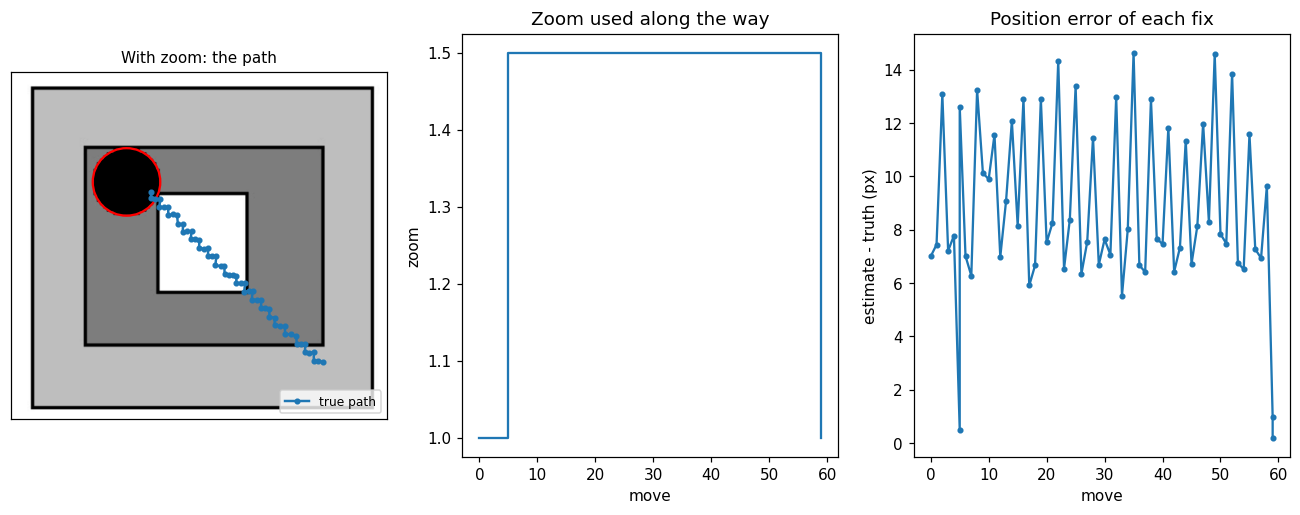

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
show_paths(axes[0], [(cam_zoom, "true path", "o-")], "With zoom: the path")
z = events.zoom.to_numpy(); m = events.moves.to_numpy()
axes[1].step(m, z, where="post"); axes[1].set_xlabel("move"); axes[1].set_ylabel("zoom"); axes[1].set_title("Zoom used along the way")
err = np.hypot(events.est_x.astype(float) - events.true_x, events.est_y.astype(float) - events.true_y)
axes[2].plot(m, err, "o-", ms=3); axes[2].set_xlabel("move"); axes[2].set_ylabel("estimate - truth (px)")
axes[2].set_title("Position error of each fix")
fig.savefig(aio.output_path("crop_navigation", "followup_with_zoom.png"), bbox_inches="tight"); plt.show()

## 5. Subtask B: without zoom

Without zoom, the camera can't step back to see more, so it plans where to look:

1. **Localisability map, computed once:** crop the view at every grid position (every 10 px) and
   ask the same localiser whether it can be placed.
2. **Route:** the cheapest path to the marker over the grid. Steps on views that can be placed are
   cheap, and cheaper the further they are from views that can't (a safety margin). Steps on views
   that can't be placed are very expensive, so the route only uses them to cross a gap between
   separate areas, where the gap is narrowest.
3. **After every move:** locate again and re-plan from that fix.
4. **If a view the map promised turns out unplaceable** (the move landed somewhere unexpected),
   undo that move once and avoid that spot.

In [7]:
import time
t0 = time.time()
lmap = cl.LocalizabilityMap(reference, loc_native, ref_det)
print("map: {} positions, {:.0%} can be located, {:.0%} have a full margin around them ({:.0f} s)"
      .format(lmap.ok.size, lmap.fraction_ok, lmap.safe.mean(), time.time() - t0))
cam_map = cl.PanCamera(reference, START, VIEW, ppc, ERR)
r_map = cl.navigate_without_zoom(cam_map, loc_native, lmap, ref_det)
print("status:", r_map.status, "| marker really in view:", truly_visible(cam_map))
print("moves:", r_map.moves, "| views it could not place:", r_map.lost_views, "| undos:", r_map.backoffs)
print("final estimate vs truth: {:.2f} px".format(r_map.final_error_px(cam_map)))

map: 1599 positions, 89% can be located, 78% have a full margin around them (17 s)


status: visible | marker really in view: True
moves: 52 | views it could not place: 0 | undos: 0
final estimate vs truth: 0.41 px


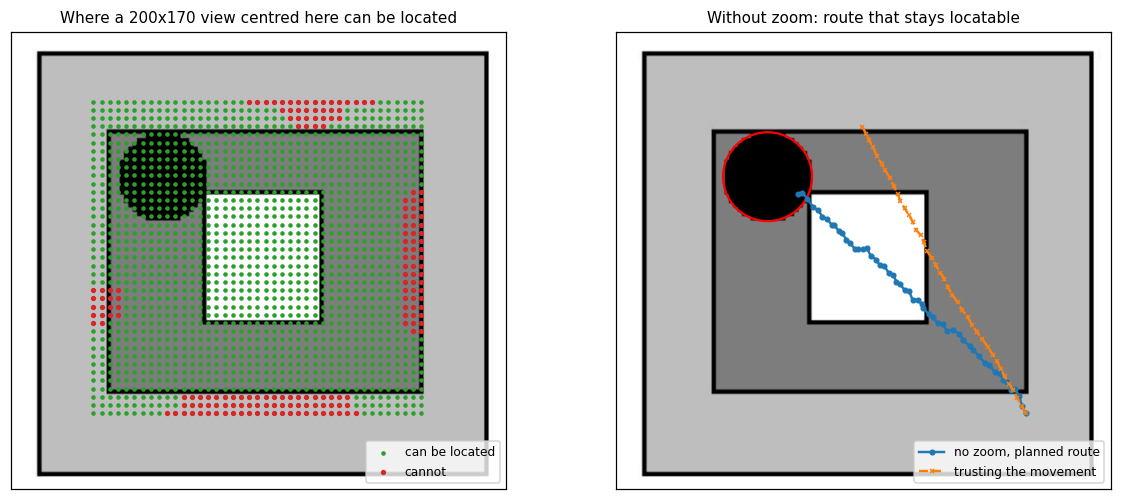

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
okc = np.array([lmap.center_of((j, i)) for j in range(lmap.ok.shape[0]) for i in range(lmap.ok.shape[1]) if lmap.ok[j, i]])
bad = np.array([lmap.center_of((j, i)) for j in range(lmap.ok.shape[0]) for i in range(lmap.ok.shape[1]) if not lmap.ok[j, i]])
viz.show(reference, "Where a 200x170 view centred here can be located", ax=axes[0])
axes[0].scatter(okc[:, 0], okc[:, 1], s=4, c="tab:green", label="can be located")
axes[0].scatter(bad[:, 0], bad[:, 1], s=6, c="tab:red", label="cannot")
axes[0].legend(loc="lower right", fontsize=8)
show_paths(axes[1], [(cam_map, "no zoom, planned route", "o-"), (cam_trust, "trusting the movement", "x--")],
           "Without zoom: route that stays locatable")
fig.savefig(aio.output_path("crop_navigation", "followup_without_zoom.png"), bbox_inches="tight"); plt.show()

## 6. Many runs, random starts, random motion errors

For each run: a random starting view (some can't be located at all), and a random motion error
per axis (50% to 150% of the commanded distance), plus bias and noise. Every method gets exactly the
same runs. "Re-localise only" re-localises after every move but has neither trick: when lost, it
searches blindly.

The same is repeated with a smaller **120 x 100** view, where far fewer views can be located.

In [9]:
def compare(view, n_runs, seed):
    lc0, lcz = cl.Localizer(reference, view), cl.Localizer(reference, view, pad=PAD)
    mp = lmap if view == VIEW else cl.LocalizabilityMap(reference, lc0, ref_det)
    H, W = reference.shape[:2]
    rng = np.random.default_rng(seed); rows = []
    for k in range(n_runs):
        start = (rng.uniform(view[0] / 2, W - view[0] / 2), rng.uniform(view[1] / 2, H - view[1] / 2))
        err = cl.MotionError(gain=tuple(rng.uniform(0.5, 1.5, 2)), bias_px=tuple(rng.uniform(-2, 2, 2)),
                             noise_px=1.5, seed=int(rng.integers(1e9)))
        for name in ["trust the movement", "re-localise only", "A: with zoom", "B: no zoom, planned route"]:
            if name == "A: with zoom":
                c = cl.PanCamera(reference, start, view, ppc, err, pad=PAD, max_zoom=3.0)
                r = cl.navigate_with_zoom(c, lcz, ref_det, reference.shape, axis_first=True)
            else:
                c = cl.PanCamera(reference, start, view, ppc, err)
                if name == "trust the movement":
                    r = cl.navigate_trusting_motion(c, lc0, ref_det, reference.shape)
                elif name == "re-localise only":
                    r = cl.navigate_with_zoom(c, lc0, ref_det, reference.shape, zoom_levels=(1.0,), axis_first=True)
                else:
                    r = cl.navigate_without_zoom(c, lc0, mp, ref_det)
            vis = navigation.marker_visible(c.true_window(), ref_det, "auto")
            rows.append({"view": f"{view[0]}x{view[1]}", "method": name, "reached": vis,
                         "claimed_but_wrong": r.status == "visible" and not vis, "moves": r.moves,
                         "lost_views": r.lost_views, "zoom_changes": r.zoom_changes, "undos": r.backoffs,
                         "final_error_px": r.final_error_px(c)})
    return pd.DataFrame(rows), mp

t0 = time.time()
df_big, _ = compare(VIEW, 40, C.RANDOM_SEED)
df_small, lmap_small = compare((120, 100), 30, C.RANDOM_SEED + 1)
print("{:.0f} s; small-view map: {:.0%} of positions can be located".format(time.time() - t0, lmap_small.fraction_ok))
allruns = pd.concat([df_big, df_small])
allruns.to_csv(aio.output_path("crop_navigation", "followup_closed_loop_runs.csv"), index=False)
summary = (allruns.groupby(["view", "method"], sort=False)
           .agg(runs=("reached", "size"), reached=("reached", "mean"), wrong_claims=("claimed_but_wrong", "sum"),
                median_moves=("moves", "median"), lost_views=("lost_views", "sum"),
                zoom_changes=("zoom_changes", "sum"), undos=("undos", "sum"),
                worst_final_error_px=("final_error_px", "max")))
summary["reached"] = (100 * summary["reached"]).round(0).astype(int).astype(str) + "%"
display(summary.round(2))
summary.to_csv(aio.output_path("crop_navigation", "followup_closed_loop_summary.csv"))

133 s; small-view map: 45% of positions can be located


runs reached  wrong_claims  median_moves  \
view    method                                                                
200x170 trust the movement           40     22%            31          17.0   
        re-localise only             40    100%             0          17.5   
        A: with zoom                 40    100%             0          17.5   
        B: no zoom, planned route    40    100%             0          17.0   
120x100 trust the movement           30     40%            18          20.0   
        re-localise only             30    100%             0          32.5   
        A: with zoom                 30    100%             0          22.0   
        B: no zoom, planned route    30    100%             0          26.0   

                                   lost_views  zoom_changes  undos  \
view    method                                                       
200x170 trust the movement                 12             0      0   
        re-localise only                   12             0      0   
        A: with zoom                        6            12      0   
        B: no zoom, planned route          12             0      0   
120x100 trust the movement                102             0      0   
        re-localise only                  355             0      0   
        A: with zoom                       45            67      0   
        B: no zoom, planned route         223             0      2   

                                   worst_final_error_px  
view    method                                           
200x170 trust the movement                       149.26  
        re-localise only                           0.57  
        A: with zoom                               0.57  
        B: no zoom, planned route                  0.62  
120x100 trust the movement                       139.54  
        re-localise only                           0.54  
        A: with zoom                               0.66  
        B: no zoom, planned route                  0.56

**How to read this**

- **Trusting the movement** fails most of the time, and in most of those failures it *claims* it
  arrived. That's the case to rule out.
- Every method that **re-localises after every move** gets there in every run, and always knows
  where it is: the final estimate is within a pixel of the truth.
- With the big view, most views can be located, so re-localising alone is nearly enough.
- With the **small view**, plain re-localising only gets there by searching blindly, with hundreds
  of views it can't place. **Zoom** needs the fewest moves. **The planned route** gets there without
  zoom by staying on locatable views and crossing gaps only where it must.

## 7. Limitations

- The camera is simulated: the scene is the flat reference image, and moves are translations parallel
  to it. Rotation, scale change from moving closer, lens distortion and lighting are not modelled.
- The zoom level is assumed to be read back exactly from the lens. A scale search in the matcher
  would remove that assumption.
- The localisability map is computed from the reference, so it assumes the scene matches it.
- During a planned crossing between separate locatable areas, the few steps without a fix rely on
  the commanded moves. That's the only place movement is trusted, and the next fix corrects it.